# S6b_Lyell_QC_2019.ipynb

Lyell watershed S1-VV QC investigation, 2019: spatial maps of QC-passing and
QC-failing pixels, per-orbit QC failure-mode composite figure, and example
backscatter-anomaly time series for representative pixels.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import importlib
import sys
import rioxarray as rxr
from pathlib import Path
import xarray as xr
import contextily as ctx
import pandas as pd


# gets rid of a lot of annoying warnings, we know there are NaNs (might want to remove this to double check)
import warnings
warnings.filterwarnings("ignore")


In [2]:
sys.path.insert(1, '../scripts/')

In [3]:
import metadata as metadata
import melt_phases as melt_phases


In [4]:
import importlib
importlib.reload(metadata)
importlib.reload(melt_phases)


<module 'melt_phases' from '/glade/u/home/rossamower/school/uw/cues_git/cues_sentinel_snowmodel/python/supporting_information/../scripts/melt_phases.py'>

## Config & geometry

In [5]:
importlib.reload(metadata)
# tuolumne
tuolumne_cfg = metadata.load_yaml(Path(f"../../configs/Tuolumne.yaml"))
# ASO
aso_cfg = metadata.load_yaml(Path(f"../../configs/ASO.yaml"))
_,aso_crs = metadata.get_shapefile_fpath(aso_cfg,"basin_shapefile","USCASJ")


## Terrain loading

In [6]:
def tif_to_shape(mask_da):
    """
    Converts a boolean xarray to a geopandas shape.
    """
  # Boolean mask (or 0/1 mask)
    mask = mask_da.values.astype(np.uint8)

    # Build affine transform from xarray coordinates
    x = mask_da.x.values
    y = mask_da.y.values

    dx = np.abs(x[1] - x[0])
    dy = np.abs(y[1] - y[0])

    transform = Affine(
        dx, 0, x.min() - dx/2,
        0, -dy, y.max() + dy/2
    )

    # Polygonize
    geoms = [
        shape(geom)
        for geom, value in shapes(mask, mask=mask.astype(bool), transform=transform)
        if value == 1
    ]

    gdf = gpd.GeoDataFrame(
        geometry=geoms,
        crs=mask_da.rio.crs
    )

    # Merge all polygons into one watershed polygon
    gdf = gdf.dissolve()  

    return gdf

In [7]:
from rasterio.features import shapes
from shapely.geometry import shape
from affine import Affine

lyell_water_shed = rxr.open_rasterio('/glade/u/home/rossamower/rmower/aso/data/shape/USCATM/raw/Lyell_Watershed.tif').squeeze(drop = True)

lyell_gdf_proj = tif_to_shape(lyell_water_shed)


In [8]:
year = 2019

# sentinel
ds_s1_vv = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}vv/{year}_wetness_phase.nc")
ds_s1_vv = ds_s1_vv.rio.write_crs(aso_crs)


# QC Investigation

In [9]:
# backscatter.
s1_bsc_ds = xr.load_dataset('/glade/campaign/ral/hap/rmower/pixel/sentinel/tuolumne/100_m/2019/bscatter/s1_backscatter_2018_10_01_2019_10_01_100m.nc').rename({'__xarray_dataarray_variable__':'bscatter'}).rio.clip(lyell_gdf_proj.geometry)
# reference.
s1_ref_ds = xr.load_dataset('/glade/campaign/ral/hap/rmower/pixel/sentinel/tuolumne/100_m/2019/melt_thresh/reference/reference_images_2018-07-15_2018-09-01.nc').rio.write_crs(aso_crs).rio.clip(lyell_gdf_proj.geometry)

In [10]:

# ── Method parameters (match fig_2) ──────────────────────────────────────────
WET_THRESH_DB = -2.0   # Rc threshold for wet snow (dB)
K       = 0.5          # weight between VH and VV in Rc
THETA1  = 20           # lower incidence angle limit (deg)
THETA2  = 45           # upper incidence angle limit (deg)

ORBITS = (64, 137, 144)   # all available orbits

"""
    METHOD CONFIGURATIONS
"""
# VV method config (Marin minima + QC)
cfg = melt_phases.MarinS1VVCfg()

# Weighted method config
cfg_w = melt_phases.WeightedMinimaCfg(
    k=K,
    theta1=THETA1,
    theta2=THETA2,
    wet_thresh_db=WET_THRESH_DB,
    cfg_marin=melt_phases.MarinS1VVCfg(
        min_stability_days=28,
        max_group_spread_days=28,
    ),
)

print("VV cfg     :", cfg)
print("Weighted cfg:", cfg_w)

VV cfg     : MarinS1VVCfg(tau_db=-3.0, frac_below_bad=0.6, max_am_pm_mismatch_days=28, max_group_spread_days=28, local_window_days=30, min_stability_days=28, min_distinct_db=0.7, persist_margin_db=0.5, persist_min_count=2)
Weighted cfg: WeightedMinimaCfg(k=0.5, theta1=20, theta2=45, wet_thresh_db=-2.0, cfg_marin=MarinS1VVCfg(tau_db=-3.0, frac_below_bad=0.6, max_am_pm_mismatch_days=28, max_group_spread_days=28, local_window_days=30, min_stability_days=28, min_distinct_db=0.7, persist_margin_db=0.5, persist_min_count=2))


### Where did it pass?

                        name                        geometry
0  Lyell below Maclure gauge  POINT (300810.399 4183616.651)
300810.39883943327 4183616.6507350826


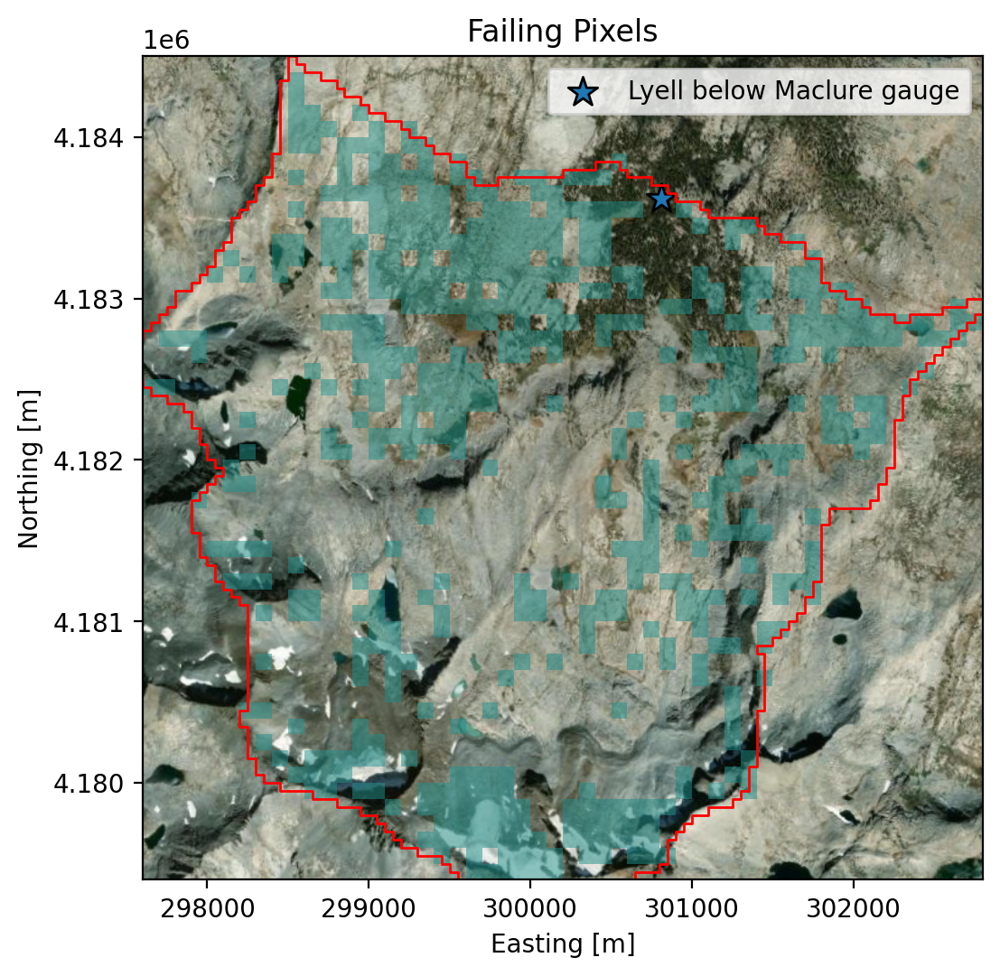

In [11]:


import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# lon, lat
lyell_blw_maclure_gauge_lon_lat = [-119.26180, 37.77821]

# Create point in WGS84
gauge_gdf = gpd.GeoDataFrame(
    {"name": ["Lyell below Maclure gauge"]},
    geometry=[Point(lyell_blw_maclure_gauge_lon_lat[0], lyell_blw_maclure_gauge_lon_lat[1])],
    crs="EPSG:4326"
)

# Reproject to UTM Zone 11N
gauge_32611 = gauge_gdf.to_crs("EPSG:32611")

print(gauge_32611)
print(gauge_32611.geometry.x.iloc[0], gauge_32611.geometry.y.iloc[0])

# Plot
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

gauge_32611.plot(
    ax=ax,
    marker="*",
    markersize=150,
    edgecolor="black",
    label="Lyell below Maclure gauge"
)
ds_s1_vv.where(ds_s1_vv.qc_ok == True).rio.clip(lyell_gdf_proj.geometry).qc_ok.plot(ax=ax,alpha = 0.5,add_colorbar=False)
lyell_gdf_proj.plot(ax=ax,color = 'none',edgecolor = 'red')
ctx.add_basemap(
    ax=ax,
    crs=aso_crs,
    source=ctx.providers.Esri.WorldImagery,
    attribution=False
)

ax.set_xlabel("Easting [m]")
ax.set_ylabel("Northing [m]")
ax.legend()
ax.set_title('Failing Pixels')

plt.show()

### Where did it fail?

                        name                        geometry
0  Lyell below Maclure gauge  POINT (300810.399 4183616.651)
300810.39883943327 4183616.6507350826


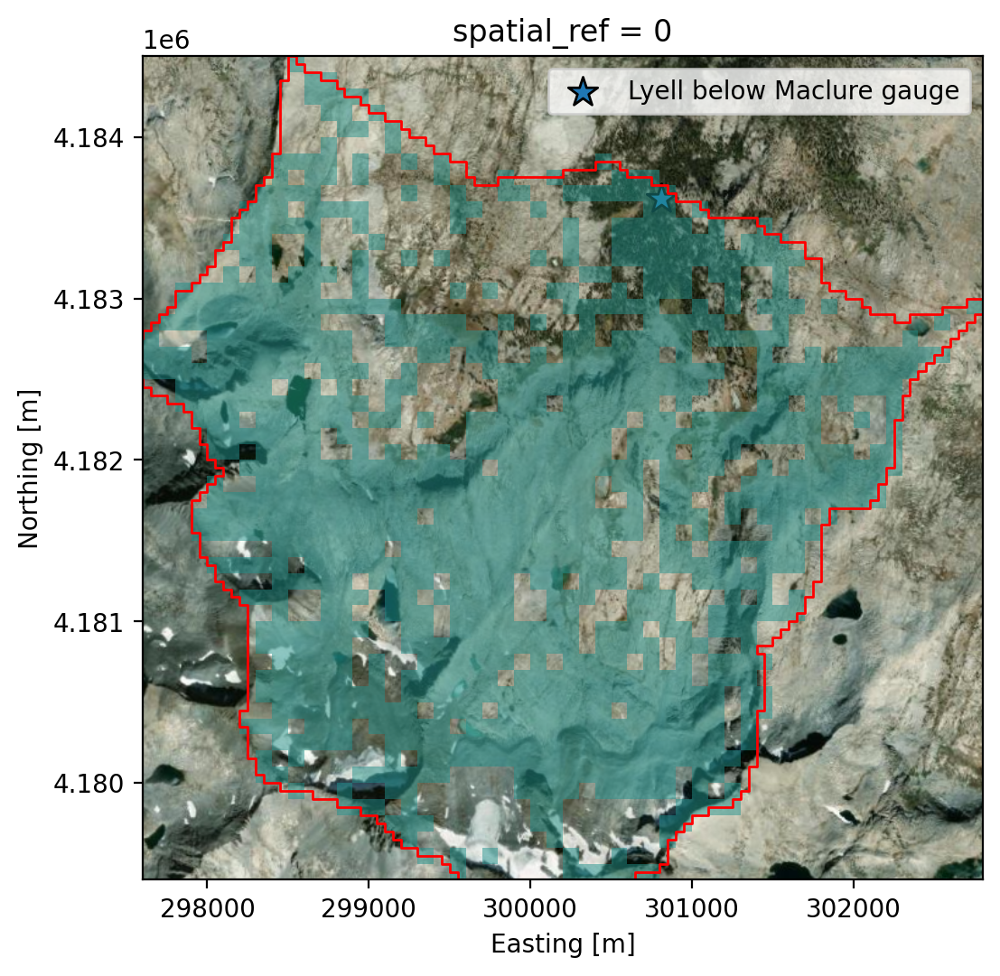

In [12]:


import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# lon, lat
lyell_blw_maclure_gauge_lon_lat = [-119.26180, 37.77821]

# Create point in WGS84
gauge_gdf = gpd.GeoDataFrame(
    {"name": ["Lyell below Maclure gauge"]},
    geometry=[Point(lyell_blw_maclure_gauge_lon_lat[0], lyell_blw_maclure_gauge_lon_lat[1])],
    crs="EPSG:4326"
)

# Reproject to UTM Zone 11N
gauge_32611 = gauge_gdf.to_crs("EPSG:32611")

print(gauge_32611)
print(gauge_32611.geometry.x.iloc[0], gauge_32611.geometry.y.iloc[0])

# Plot
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

gauge_32611.plot(
    ax=ax,
    marker="*",
    markersize=150,
    edgecolor="black",
    label="Lyell below Maclure gauge"
)
ds_s1_vv.where(ds_s1_vv.qc_ok == False).rio.clip(lyell_gdf_proj.geometry).qc_ok.plot(ax=ax,alpha = 0.5,add_colorbar=False)
lyell_gdf_proj.plot(ax=ax,color = 'none',edgecolor = 'red')
ctx.add_basemap(
    ax=ax,
    crs=aso_crs,
    source=ctx.providers.Esri.WorldImagery,
    attribution=False
)

ax.set_xlabel("Easting [m]")
ax.set_ylabel("Northing [m]")
ax.legend()

plt.show()

### Why did it fail?

In [13]:
def failure_mech(dict,orbit_str):
    per_orbit_dict = dict['diagnostics']['per_orbit'][orbit_str]
    return per_orbit_dict['reason']
        

def backscatter_anomalies(
    ds_s1,
    s1_bsc_ds,
    s1_ref_ds,
    idx_=None,
    idy_=None,
    model='s1-vv',
    qcPass=True,
    geog: gpd.GeoDataFrame = None,
    showPlot: bool = True,
):
    TAU_DB = -2.0  # VV drop threshold (dB)

    # -- Pixel selection -------------------------------------------------------
    qc_ok = ds_s1['qc_ok'].values

    if idx_ is None or idy_ is None:
        y_min, y_max = float(s1_bsc_ds.y.min()), float(s1_bsc_ds.y.max())
        x_min, x_max = float(s1_bsc_ds.x.min()), float(s1_bsc_ds.x.max())
        yy, xx = np.meshgrid(ds_s1.y.values, ds_s1.x.values, indexing='ij')
        spatial_mask  = (yy >= y_min) & (yy <= y_max) & (xx >= x_min) & (xx <= x_max)
        combined_mask = (qc_ok == qcPass) & spatial_mask
        valid_yx = np.argwhere(combined_mask)
        if len(valid_yx) == 0:
            raise ValueError(f"No pixels with qc_ok == {qcPass} within s1_bsc_ds extent")
        chosen     = valid_yx[np.random.randint(len(valid_yx))]
        idy_, idx_ = int(chosen[0]), int(chosen[1])

    y_val    = float(ds_s1.y.values[idy_])
    x_val    = float(ds_s1.x.values[idx_])
    pixel_qc = bool(qc_ok[idy_, idx_])
    print(f"Pixel  idy={idy_}, idx={idx_}  |  y={y_val:.1f}, x={x_val:.1f}  |  qc_ok={pixel_qc}")

    # -- Extract per-time VV backscatter at this pixel (linear -> dB) ----------
    times        = s1_bsc_ds['time'].values
    orbits       = s1_bsc_ds['sat:relative_orbit'].values   # shape (time,)
    orbit_states = s1_bsc_ds['sat:orbit_state'].values      # shape (time,)

    bsc_vv_linear = (
        s1_bsc_ds['bscatter']
        .sel(y=y_val, x=x_val, method='nearest')
        .sel(band='vv')
        .values   # shape (time,), linear units
    )
    bsc_vv_db = 10.0 * np.log10(bsc_vv_linear)  # convert to dB

    # -- Compute DVV per orbit: ref also linear -> dB, then subtract -----------
    delta_vv = np.full(len(times), np.nan)
    for orbit in np.unique(orbits):
        t_mask = orbits == orbit
        ref_linear = float(
            s1_ref_ds['reference_bscatter']
            .sel(**{'sat:relative_orbit': int(orbit)}, band='vv')
            .sel(y=y_val, x=x_val, method='nearest')
            .values
        )
        ref_db = 10.0 * np.log10(ref_linear)
        delta_vv[t_mask] = bsc_vv_db[t_mask] - ref_db
        if showPlot:
            print(f"  orbit {int(orbit):3d}  ref_linear={ref_linear:.4f}  ref_db={ref_db:.2f} dB  "
                  f"DVV range [{np.nanmin(delta_vv[t_mask]):.2f}, {np.nanmax(delta_vv[t_mask]):.2f}] dB")

    # -- Split by orbit and pass/fail threshold --------------------------------
    am_mask  = orbit_states == 'descending'          # orbit 144
    pm64_mask  = (orbit_states == 'ascending') & (orbits == 64)
    pm137_mask = (orbit_states == 'ascending') & (orbits == 137)

    # -- Print reason for failure ----------------------------------------------
    if model == 's1-vv':
        result = melt_phases.run_s1_vv_year(s1_bsc_ds, s1_ref_ds, idy=idy_, idx=idx_, year=2019, cfg=melt_phases.MarinS1VVCfg())
    else:
        result = melt_phases.run_s1_rc_year_from_ts(s1_bsc_ds, 
                                                    s1_ref_ds, 
                                                    idy=idy_, 
                                                    idx=idx_, 
                                                    year=2019, 
                                                    cfg=melt_phases.MarinS1VVCfg()
                                                   )
    # print(result['qc_ok'], result['qc_reason'])
    # print(result['diagnostics']['per_orbit'])
    reason_64 = failure_mech(result,'64')
    reason_137 = failure_mech(result,'137')
    reason_144 = failure_mech(result,'144')
    if showPlot:
        print(f'Failure 64: {reason_64}')
        print(f'Failure 137: {reason_137}')
        print(f'Failure 144: {reason_144}')

    # -- Plot ------------------------------------------------------------------
    if showPlot:
        fig, ax = plt.subplots(1, 2, figsize=(13, 6), dpi=200)

        # Spatial panel
        ds_s1.where(ds_s1.qc_ok == qcPass).qc_ok.plot(ax=ax[0], alpha=0.5, add_colorbar=False)
        ax[0].scatter(ds_s1.x[idx_], ds_s1.y[idy_], label='sel pix', color = 'red',zorder=5)
        ax[0].legend()
        ax[0].set_title('')
        ax[0].axis('off')
        if geog is not None: geog.plot(ax=ax[0], color='none', edgecolor='red')
        ctx.add_basemap(ax=ax[0], crs=aso_crs, source=ctx.providers.Esri.WorldImagery, attribution=False)

        # Time series panel — AM and each PM orbit separately
        if am_mask.any():
            ax[1].plot(times[am_mask], delta_vv[am_mask], color='steelblue', linewidth=1.2, alpha=0.7, zorder=2)
            ax[1].scatter(times[am_mask], delta_vv[am_mask], color='steelblue', s=18, zorder=3,
                      label=r'$\Delta\sigma_{AM}$ (orbit 144, desc.)')
        if pm64_mask.any():
            ax[1].plot(times[pm64_mask], delta_vv[pm64_mask], color='red', linewidth=1.2, alpha=0.7, zorder=2)
            ax[1].scatter(times[pm64_mask], delta_vv[pm64_mask], color='red', s=18, zorder=3,
                      label=r'$\Delta\sigma_{PM}$ (orbit 64, asc.)')
        if pm137_mask.any():
            ax[1].plot(times[pm137_mask], delta_vv[pm137_mask], color='darkorange', linewidth=1.2, alpha=0.7, zorder=2)
            ax[1].scatter(times[pm137_mask], delta_vv[pm137_mask], color='darkorange', s=18, zorder=3,
                      label=r'$\Delta\sigma_{PM}$ (orbit 137, asc.)')

        ax[1].axhline(TAU_DB, color='black', linestyle='--', linewidth=1.2,
                      label=f'Drop Threshold ({TAU_DB} dB)')
        ax[1].axhline(0, color='gray', linestyle='-', linewidth=0.7, alpha=0.5)

        qc_label = 'QC Pass' if pixel_qc else 'QC Fail'
        ax[1].set_title(f'DVV Backscatter Anomaly  |  idy={idy_}, idx={idx_}  [{qc_label}]', fontweight='bold')
        ax[1].set_xlabel('Time')
        ax[1].set_ylabel(r'$\Delta\sigma^0_{VV}$ [dB]')
        ax[1].legend(fontsize=8)
        ax[1].grid(True, alpha=0.3)

        plt.tight_layout()

    return reason_64,reason_137,reason_144


In [14]:
def create_keys(dict,reason,count_dict):
    if reason in dict.values():
        pass
    else:
        dict[count_dict] = reason
        count_dict += 1
    return dict,count_dict
        

In [15]:
qc_fail_da = ds_s1_vv.where(ds_s1_vv.qc_ok == False).rio.clip(lyell_gdf_proj.geometry).qc_ok

failur_arr_64 = np.full((qc_fail_da.y.shape[0], qc_fail_da.x.shape[0]), -1)
failur_arr_137 = np.full((qc_fail_da.y.shape[0], qc_fail_da.x.shape[0]), -1)
failur_arr_144 = np.full((qc_fail_da.y.shape[0], qc_fail_da.x.shape[0]), -1)
count = 0
count_dict= {0:'OK'}
dict_count = 1
for j in range(qc_fail_da.y.shape[0]):
    for i in range(qc_fail_da.y.shape[0]):
        if qc_fail_da[j,i] == 0:
            reason_64,reason_137,reason_144 = backscatter_anomalies(ds_s1_vv.rio.clip(lyell_gdf_proj.geometry),
                                  s1_bsc_ds,
                                  s1_ref_ds,
                                  idx_=i,
                                  idy_=j,
                                  model='s1-vv',
                                  qcPass = False,
                                  geog=lyell_gdf_proj,
                                  showPlot = False,
                                )
            count_dict,dict_count = create_keys(count_dict,reason_64,dict_count)
            count_dict,dict_count = create_keys(count_dict,reason_137,dict_count)
            count_dict,dict_count = create_keys(count_dict,reason_144,dict_count)
            
            failur_arr_64[j,i] = next(k for k, v in count_dict.items() if v == reason_64)
            failur_arr_137[j,i] = next(k for k, v in count_dict.items() if v == reason_137)
            failur_arr_144[j,i] = next(k for k, v in count_dict.items() if v == reason_144)
            count += 1
            # print(j,i)
            #     # -- Print reason for failure ----------------------------------------------
            # result = melt_phases.run_s1_vv_year(s1_bsc_ds, s1_ref_ds, idy=j, idx=i, year=2019, cfg=melt_phases.MarinS1VVCfg())
            # print(result['qc_ok'], result['qc_reason'])
            # print(result['diagnostics']['per_orbit'])


Pixel  idy=0, idx=9  |  y=4184450.0, x=298550.0  |  qc_ok=False
Pixel  idy=1, idx=10  |  y=4184350.0, x=298650.0  |  qc_ok=False
Pixel  idy=1, idx=11  |  y=4184350.0, x=298750.0  |  qc_ok=False
Pixel  idy=2, idx=10  |  y=4184250.0, x=298650.0  |  qc_ok=False
Pixel  idy=2, idx=11  |  y=4184250.0, x=298750.0  |  qc_ok=False
Pixel  idy=2, idx=12  |  y=4184250.0, x=298850.0  |  qc_ok=False
Pixel  idy=2, idx=13  |  y=4184250.0, x=298950.0  |  qc_ok=False
Pixel  idy=3, idx=11  |  y=4184150.0, x=298750.0  |  qc_ok=False
Pixel  idy=3, idx=12  |  y=4184150.0, x=298850.0  |  qc_ok=False
Pixel  idy=3, idx=14  |  y=4184150.0, x=299050.0  |  qc_ok=False
Pixel  idy=4, idx=12  |  y=4184050.0, x=298850.0  |  qc_ok=False
Pixel  idy=4, idx=13  |  y=4184050.0, x=298950.0  |  qc_ok=False
Pixel  idy=4, idx=15  |  y=4184050.0, x=299150.0  |  qc_ok=False
Pixel  idy=5, idx=11  |  y=4183950.0, x=298750.0  |  qc_ok=False
Pixel  idy=5, idx=15  |  y=4183950.0, x=299150.0  |  qc_ok=False
Pixel  idy=6, idx=8  |  y=

In [16]:
def np_to_da(np,ref_da):
    da = xr.DataArray(
        data=np,
        dims = ["y","x"],
        coords=dict(
            y=(["y"],ref_da.y.values),
            x=(["x"],ref_da.x.values),
        )
    )
    da = da.rio.write_crs(ref_da.rio.crs)
    return da

In [17]:
# backscatter.
s1_bsc_prev_ds = xr.load_dataset('/glade/campaign/ral/hap/rmower/pixel/sentinel/tuolumne/100_m/2018/bscatter/s1_backscatter_2017_10_01_2018_10_01_100m.nc').rename({'__xarray_dataarray_variable__':'bscatter'}).rio.clip(lyell_gdf_proj.geometry)

                        name                        geometry
0  Lyell below Maclure gauge  POINT (300810.399 4183616.651)
300810.39883943327 4183616.6507350826


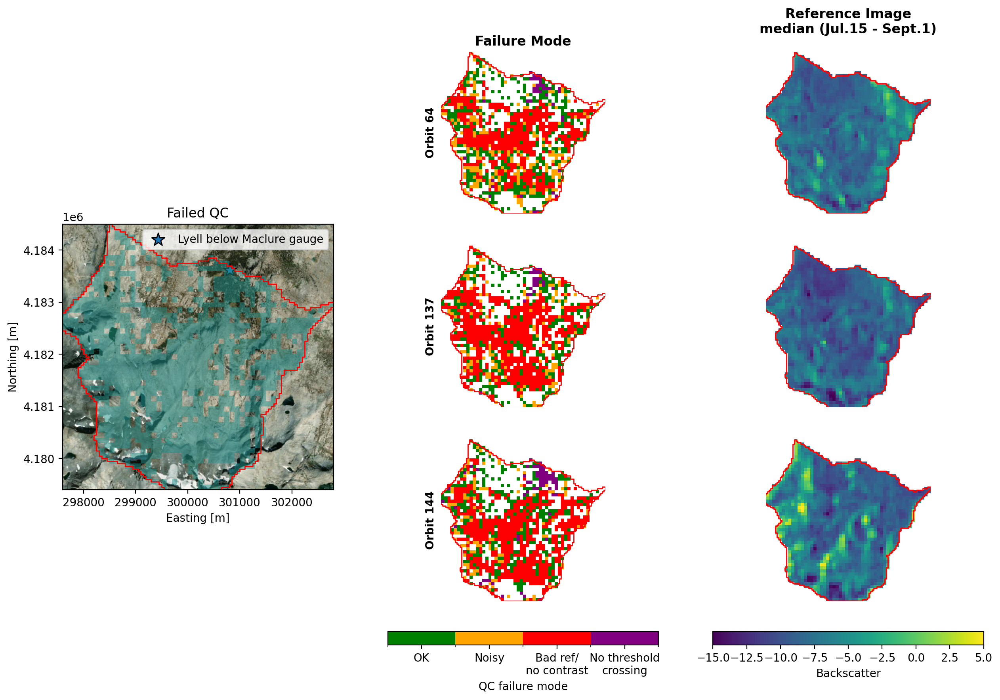

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

import matplotlib.colors as mcolors

failure_labels = {
    0: "OK",
    1: "NOISY_SIGNAL",
    2: "BAD_REFERENCE_OR_NO_CONTRAST",
    3: "NO_THRESHOLD_CROSSING",
}

failure_cmap = mcolors.ListedColormap([
    "green",      # OK
    "orange",     # NOISY_SIGNAL
    "red",        # BAD_REFERENCE_OR_NO_CONTRAST
    "purple",     # NO_THRESHOLD_CROSSING
])

failure_norm = mcolors.BoundaryNorm(
    boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5],
    ncolors=failure_cmap.N
)

# lon, lat
lyell_blw_maclure_gauge_lon_lat = [-119.26180, 37.77821]

# Create point in WGS84
gauge_gdf = gpd.GeoDataFrame(
    {"name": ["Lyell below Maclure gauge"]},
    geometry=[Point(lyell_blw_maclure_gauge_lon_lat[0], lyell_blw_maclure_gauge_lon_lat[1])],
    crs="EPSG:4326"
)

# Reproject to UTM Zone 11N
gauge_32611 = gauge_gdf.to_crs("EPSG:32611")

print(gauge_32611)
print(gauge_32611.geometry.x.iloc[0], gauge_32611.geometry.y.iloc[0])

# Plot
fig = plt.figure(figsize=(15, 10), dpi=200)
gs = fig.add_gridspec(3, 3)

# Big map axis spanning all rows in column 0
ax_map = fig.add_subplot(gs[:, 0])

# Three smaller axes in column 1
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[2, 1])

# Three smaller axes in column 1
ax4 = fig.add_subplot(gs[0, 2])
ax5 = fig.add_subplot(gs[1, 2])
ax6 = fig.add_subplot(gs[2, 2])

gauge_32611.plot(
    ax=ax_map,
    marker="*",
    markersize=150,
    edgecolor="black",
    label="Lyell below Maclure gauge"
)
ds_s1_vv.where(ds_s1_vv.qc_ok == False).rio.clip(lyell_gdf_proj.geometry).qc_ok.plot(ax=ax_map,alpha = 0.5,add_colorbar=False)
lyell_gdf_proj.plot(ax=ax_map,color = 'none',edgecolor = 'red')
ctx.add_basemap(
    ax=ax_map,
    crs=aso_crs,
    source=ctx.providers.Esri.WorldImagery,
    attribution=False
)

ax_map.set_xlabel("Easting [m]")
ax_map.set_ylabel("Northing [m]")
ax_map.legend()
ax_map.set_title('Failed QC')

fail_64_da = np_to_da(failur_arr_64,ds_s1_vv.rio.clip(lyell_gdf_proj.geometry))
fail_137_da = np_to_da(failur_arr_137,ds_s1_vv.rio.clip(lyell_gdf_proj.geometry))
fail_144_da = np_to_da(failur_arr_144,ds_s1_vv.rio.clip(lyell_gdf_proj.geometry))

m1 = fail_64_da.where(fail_64_da > -1).plot(
    ax=ax1,
    cmap=failure_cmap,
    norm=failure_norm,
    add_colorbar=False
)

fail_137_da.where(fail_137_da > -1).plot(
    ax=ax2,
    cmap=failure_cmap,
    norm=failure_norm,
    add_colorbar=False
)

fail_144_da.where(fail_144_da > -1).plot(
    ax=ax3,
    cmap=failure_cmap,
    norm=failure_norm,
    add_colorbar=False
)

# fail_64_da.where(fail_64_da > -1).plot(ax=ax1,add_colorbar = False)
lyell_gdf_proj.plot(ax=ax1,color = 'none',edgecolor = 'red')
ax1.set_title('Failure Mode',fontweight = 'bold')
ax1.set_ylabel('Orbit 64',fontweight = 'bold')
# ax1.axis('off')

# fail_137_da.where(fail_137_da > -1).plot(ax=ax2,add_colorbar = False)
lyell_gdf_proj.plot(ax=ax2,color = 'none',edgecolor = 'red')
ax2.set_ylabel('Orbit 137',fontweight = 'bold')
ax2.set_title('')
# ax2.axis('off')

# fail_144_da.where(fail_144_da > -1).plot(ax=ax3,add_colorbar = False)
lyell_gdf_proj.plot(ax=ax3,color = 'none',edgecolor = 'red')
ax3.set_ylabel('Orbit 144',fontweight = 'bold')
ax3.set_title('')
# ax3.axis('off')

for ax_ in [ax1,ax2,ax3]:
    ax_.set_xticklabels([])
    ax_.set_yticklabels([])
    ax_.set_xlabel('')
    ax_.set_xticks([])
    ax_.set_yticks([])
    ax_.spines['top'].set_visible(False)
    ax_.spines['right'].set_visible(False)
    ax_.spines['bottom'].set_visible(False)
    ax_.spines['left'].set_visible(False)

m2 = (10*np.log10(s1_ref_ds.where(s1_ref_ds.band == 'vv',drop = True).where(s1_ref_ds['sat:relative_orbit'] == 64,drop = True).reference_bscatter[0,0,:,:])).plot(ax=ax4,vmax = 5,vmin = -15,add_colorbar = False)
(10*np.log10(s1_ref_ds.where(s1_ref_ds.band == 'vv',drop = True).where(s1_ref_ds['sat:relative_orbit'] == 137,drop = True).reference_bscatter[0,0,:,:])).plot(ax=ax5,vmax = 5,vmin = -15,add_colorbar = False)
(10*np.log10(s1_ref_ds.where(s1_ref_ds.band == 'vv',drop = True).where(s1_ref_ds['sat:relative_orbit'] == 144,drop = True).reference_bscatter[0,0,:,:])).plot(ax=ax6,vmax = 5,vmin = -15,add_colorbar = False)
ax4.set_title('Reference Image\nmedian (Jul.15 - Sept.1)',fontweight = 'bold')

lyell_gdf_proj.plot(ax=ax4,color = 'none',edgecolor = 'red')
lyell_gdf_proj.plot(ax=ax5,color = 'none',edgecolor = 'red')
lyell_gdf_proj.plot(ax=ax6,color = 'none',edgecolor = 'red')
for ax_ in [ax4,ax5,ax6]:
    ax_.axis('off')
ax5.set_title('')
ax6.set_title('')

cbar = fig.colorbar(
    m1,
    ax=[ax1, ax2, ax3],
    orientation="horizontal",
    fraction=0.05,
    pad=0.05,
    ticks=[0, 1, 2, 3]
)

cbar.ax.set_xticklabels([
    "OK",
    "Noisy",
    "Bad ref/\nno contrast",
    "No threshold\ncrossing"
])

cbar.set_label("QC failure mode")

cbar2 = fig.colorbar(
    m2,
    ax=[ax4, ax5, ax6],
    orientation="horizontal",
    fraction=0.05,
    pad=0.05,
    # ticks=[0, 1, 2, 3]
)
cbar2.set_label("Backscatter")

plt.savefig("./pngs/S11_Lyell_S1_VV_QC_Failure_Modes_2019.png",dpi = 300)

plt.show()

# Sentinel Signal Investigation

### Data
- ds_s1_vv -- S1-VV phases
- ds_s1_rc -- S1-Rc phases
- s1_bsc_ds -- raw bscatter.
- s1_ref_ds -- reference image.

In [19]:
s1_bsc_long_ds = xr.concat([s1_bsc_prev_ds,s1_bsc_ds],dim = 'time')

In [20]:
def backscatter_anomalies(
    ds_s1,
    s1_bsc_ds,
    s1_ref_ds,
    idx_=None,
    idy_=None,
    model='s1-vv',
    qcPass=True,
    geog: gpd.GeoDataFrame = None,
    xmin_: str = None,
    xmax_: str = None,
    showRef_Period: bool = False,
    dropOrbit64: bool = False,
    basin_msk = None,
):
    sim_year = int(np.unique(ds_s1.time.dt.year.values))
    TAU_DB = -2.0  # VV drop threshold (dB)

    # -- Pixel selection -------------------------------------------------------
    qc_ok = ds_s1['qc_ok'].values

    if idx_ is None or idy_ is None:
        y_min, y_max = float(s1_bsc_ds.y.min()), float(s1_bsc_ds.y.max())
        x_min, x_max = float(s1_bsc_ds.x.min()), float(s1_bsc_ds.x.max())
        yy, xx = np.meshgrid(ds_s1.y.values, ds_s1.x.values, indexing='ij')
        spatial_mask  = (yy >= y_min) & (yy <= y_max) & (xx >= x_min) & (xx <= x_max)
        combined_mask = (qc_ok == qcPass) & spatial_mask
        valid_yx = np.argwhere(combined_mask)
        if len(valid_yx) == 0:
            raise ValueError(f"No pixels with qc_ok == {qcPass} within s1_bsc_ds extent")
        chosen     = valid_yx[np.random.randint(len(valid_yx))]
        idy_, idx_ = int(chosen[0]), int(chosen[1])

    y_val    = float(ds_s1.y.values[idy_])
    x_val    = float(ds_s1.x.values[idx_])
    pixel_qc = bool(qc_ok[idy_, idx_])
    print(f"Pixel  idy={idy_}, idx={idx_}  |  y={y_val:.1f}, x={x_val:.1f}  |  qc_ok={pixel_qc}")

    # -- Extract per-time VV backscatter at this pixel (linear -> dB) ----------
    times        = s1_bsc_ds['time'].values
    orbits       = s1_bsc_ds['sat:relative_orbit'].values   # shape (time,)
    orbit_states = s1_bsc_ds['sat:orbit_state'].values      # shape (time,)

    bsc_vv_linear = (
        s1_bsc_ds['bscatter']
        .sel(y=y_val, x=x_val, method='nearest')
        .sel(band='vv')
        .values   # shape (time,), linear units
    )
    bsc_vv_db = 10.0 * np.log10(bsc_vv_linear)  # convert to dB

    # -- Compute DVV per orbit: ref also linear -> dB, then subtract -----------
    delta_vv = np.full(len(times), np.nan)
    for orbit in np.unique(orbits):
        t_mask = orbits == orbit
        ref_linear = float(
            s1_ref_ds['reference_bscatter']
            .sel(**{'sat:relative_orbit': int(orbit)}, band='vv')
            .sel(y=y_val, x=x_val, method='nearest')
            .values
        )
        ref_db = 10.0 * np.log10(ref_linear)
        delta_vv[t_mask] = bsc_vv_db[t_mask] - ref_db
        print(f"  orbit {int(orbit):3d}  ref_linear={ref_linear:.4f}  ref_db={ref_db:.2f} dB  "
              f"DVV range [{np.nanmin(delta_vv[t_mask]):.2f}, {np.nanmax(delta_vv[t_mask]):.2f}] dB")

    # -- Split by orbit and pass/fail threshold --------------------------------
    am_mask  = orbit_states == 'descending'          # orbit 144
    pm64_mask  = (orbit_states == 'ascending') & (orbits == 64)
    pm137_mask = (orbit_states == 'ascending') & (orbits == 137)

    # -- Print reason for failure ----------------------------------------------
    result = melt_phases.run_s1_vv_year(s1_bsc_ds, s1_ref_ds, idy=idy_, idx=idx_, year=sim_year, cfg=melt_phases.MarinS1VVCfg())
    print(result['qc_ok'], result['qc_reason'])
    print(result['diagnostics']['per_orbit'])

    # -- Plot ------------------------------------------------------------------
    fig, ax = plt.subplots(1, 2, figsize=(13, 6), dpi=200)

    # Spatial panel
    if basin_msk is None:
        ds_s1.where(ds_s1.qc_ok == qcPass).qc_ok.plot(ax=ax[0], alpha=0.5, add_colorbar=False)
    else:
        ds_s1.where(ds_s1.qc_ok == qcPass).where(basin_msk).qc_ok.plot(ax=ax[0], alpha=0.5, add_colorbar=False)
    ax[0].scatter(ds_s1.x[idx_], ds_s1.y[idy_], label='sel pix', color = 'red',zorder=5)
    ax[0].legend()
    ax[0].set_title('')
    ax[0].axis('off')
    if geog is not None: geog.plot(ax=ax[0], color='none', edgecolor='red')
    ctx.add_basemap(ax=ax[0], crs=aso_crs, source=ctx.providers.Esri.WorldImagery, attribution=False)

    # Time series panel — AM and each PM orbit separately
    if am_mask.any():
        ax[1].plot(times[am_mask], delta_vv[am_mask], color='steelblue', linewidth=1.2, alpha=0.7, zorder=2)
        ax[1].scatter(times[am_mask], delta_vv[am_mask], color='steelblue', s=18, zorder=3,
                      label=r'$\Delta\sigma_{AM}$ (orbit 144, desc.)')
    if dropOrbit64:
        pass
    else:
        if pm64_mask.any():
            ax[1].plot(times[pm64_mask], delta_vv[pm64_mask], color='red', linewidth=1.2, alpha=0.7, zorder=2)
            ax[1].scatter(times[pm64_mask], delta_vv[pm64_mask], color='red', s=18, zorder=3,
                      label=r'$\Delta\sigma_{PM}$ (orbit 64, asc.)')
    if pm137_mask.any():
        ax[1].plot(times[pm137_mask], delta_vv[pm137_mask], color='darkorange', linewidth=1.2, alpha=0.7, zorder=2)
        ax[1].scatter(times[pm137_mask], delta_vv[pm137_mask], color='darkorange', s=18, zorder=3,
                      label=r'$\Delta\sigma_{PM}$ (orbit 137, asc.)')

    ax[1].axhline(TAU_DB, color='black', linestyle='--', linewidth=1.2,
                  label=f'Drop Threshold ({TAU_DB} dB)')
    ax[1].axhline(0, color='gray', linestyle='-', linewidth=0.7, alpha=0.5)
    if showRef_Period:
        start = pd.Timestamp(f"{sim_year-1}-07-15")
        end   = pd.Timestamp(f"{sim_year-1}-09-01")
        ax[1].axvline(start, color='k', linestyle='--')
        ax[1].axvline(end, color='k', linestyle='--')

        # Shade between them
        ax[1].axvspan(start, end, color='lightgray', label = 'Reference image\naggregate period',alpha=0.7,zorder = 99)

    qc_label = 'QC Pass' if pixel_qc else 'QC Fail'
    ax[1].set_title(f'DVV Backscatter Anomaly  |  idy={idy_}, idx={idx_}  [{qc_label}]', fontweight='bold')
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel(r'$\Delta\sigma^0_{VV}$ [dB]')
    ax[1].legend(fontsize=8)
    if (xmin_ is not None) and (xmax_ is not None):
        ax[1].set_xlim(np.datetime64(xmin_),np.datetime64(xmax_))
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, ax


In [21]:
ds_s1_vv_lyell = ds_s1_vv.rio.clip(lyell_gdf_proj.geometry)


In [22]:
from rasterio.features import geometry_mask
import xarray as xr

template = ds_s1_vv_lyell.qc_ok

mask = geometry_mask(
    lyell_gdf_proj.geometry,
    transform=template.rio.transform(),
    invert=True,          # True inside polygon
    out_shape=template.shape,
)

basin_mask = xr.DataArray(
    mask,
    coords=template.coords,
    dims=template.dims,
)


Pixel  idy=13, idx=24  |  y=4183150.0, x=300050.0  |  qc_ok=True
  orbit  64  ref_linear=0.0905  ref_db=-10.43 dB  DVV range [-7.89, 4.03] dB
  orbit 137  ref_linear=0.0762  ref_db=-11.18 dB  DVV range [-7.84, 2.19] dB
  orbit 144  ref_linear=0.1077  ref_db=-9.68 dB  DVV range [-7.35, 3.11] dB
True OK
{'64': {'ok': True, 'reason': 'OK', 'ref': -10.431583404541016, 't_min': Timestamp('2019-05-11 01:50:34.551724'), 'a_min': -7.888671875, 'f_below': 0.391304347826087, 'noisy_diag': {'jackknife_spread_days': 12.0, 'local_n': 8, 'distinct_q10_minus_min_db': 0.0576501846313473, 'local_low_count': 2, 'stability_fail': False, 'distinct_fail': True, 'persist_fail': False, 'noisy': False}}, '137': {'ok': True, 'reason': 'OK', 'ref': -11.177780151367188, 't_min': Timestamp('2019-05-04 01:58:56.859162'), 'a_min': -7.836214065551758, 'f_below': 0.4074074074074074, 'noisy_diag': {'jackknife_spread_days': 12.0, 'local_n': 9, 'distinct_q10_minus_min_db': 0.7220352172851561, 'local_low_count': 1, 'stab

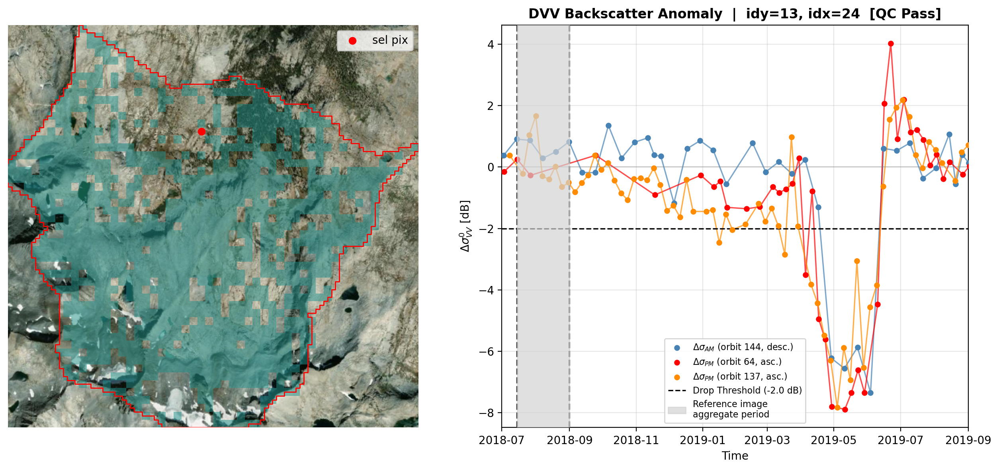

In [28]:

# Random QC-passing pixel
fig, ax = backscatter_anomalies(ds_s1_vv_lyell, 
                                s1_bsc_long_ds, 
                                s1_ref_ds, 
                                qcPass=False,
                                model = 's1-vv',
                                idx_=24,#21,#21
                                idy_=13,#9,#11
                                geog=lyell_gdf_proj,
                                xmin_ = '2018-07-01',
                                xmax_ = '2019-09-01',
                                showRef_Period = True,
                                dropOrbit64 = False,
                                basin_msk = basin_mask,
                                )
plt.savefig("./pngs/S12_Lyell_S1_VV_QC_Pass_Ex1.png",dpi = 300)
plt.show()

Pixel  idy=19, idx=8  |  y=4182550.0, x=298450.0  |  qc_ok=False
  orbit  64  ref_linear=0.1424  ref_db=-8.47 dB  DVV range [-9.47, 1.29] dB
  orbit 137  ref_linear=0.1148  ref_db=-9.40 dB  DVV range [-8.99, 1.10] dB
  orbit 144  ref_linear=0.5136  ref_db=-2.89 dB  DVV range [-9.24, 2.99] dB
False NO_GOOD_MORNING_ORBIT
{'64': {'ok': False, 'reason': 'BAD_REFERENCE_OR_NO_CONTRAST', 'ref': -8.466140747070312, 't_min': Timestamp('2019-04-29 01:50:34.349514'), 'a_min': -9.466306686401367, 'f_below': 0.7391304347826086}, '137': {'ok': False, 'reason': 'BAD_REFERENCE_OR_NO_CONTRAST', 'ref': -9.398862838745117, 't_min': Timestamp('2019-05-28 01:58:57.976020'), 'a_min': -8.987674713134766, 'f_below': 0.9259259259259259}, '144': {'ok': False, 'reason': 'BAD_REFERENCE_OR_NO_CONTRAST', 'ref': -2.894073963165283, 't_min': Timestamp('2019-06-03 13:59:46.341047'), 'a_min': -9.241130828857422, 'f_below': 0.7142857142857143}}


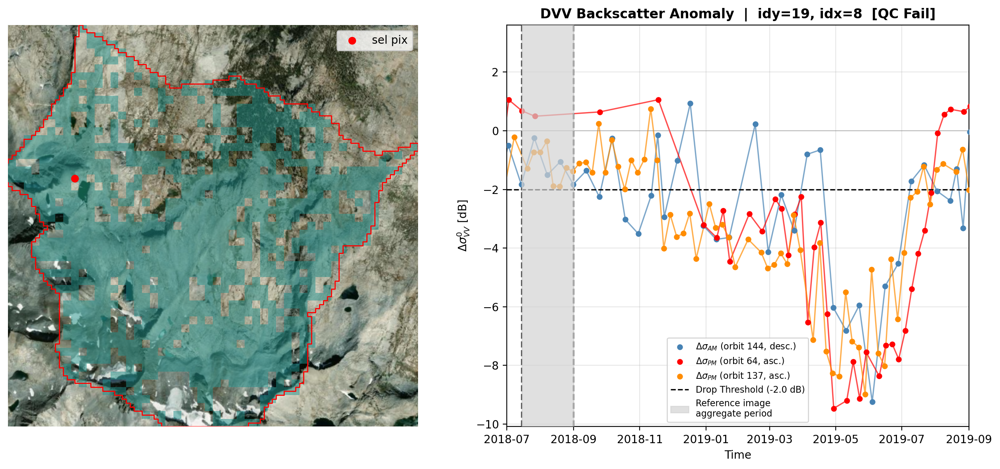

In [29]:

# Random QC-passing pixel
fig, ax = backscatter_anomalies(ds_s1_vv_lyell, 
                                s1_bsc_long_ds, 
                                s1_ref_ds, 
                                qcPass=False,
                                model = 's1-vv',
                                idx_=8,#21,#21
                                idy_=19,#9,#11
                                geog=lyell_gdf_proj,
                                xmin_ = '2018-07-01',
                                xmax_ = '2019-09-01',
                                showRef_Period = True,
                                dropOrbit64 = False,
                                basin_msk = basin_mask,
                                )
plt.savefig("./pngs/S13_Lyell_S1_VV_QC_Fail_Ex1.png",dpi = 300)
plt.show()

# Appendix

In [25]:
from rasterio.features import geometry_mask
import xarray as xr

template = ds_s1_vv_lyell.qc_ok

mask = geometry_mask(
    lyell_gdf_proj.geometry,
    transform=template.rio.transform(),
    invert=True,          # True inside polygon
    out_shape=template.shape,
)

basin_mask = xr.DataArray(
    mask,
    coords=template.coords,
    dims=template.dims,
)
basin_mask

<xarray.DataArray (y: 51, x: 52)> Size: 3kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * y            (y) float64 408B 4.184e+06 4.184e+06 ... 4.18e+06 4.179e+06
  * x            (x) float64 416B 2.976e+05 2.978e+05 ... 3.026e+05 3.028e+05
    spatial_ref  int64 8B 0

Pixel  idy=10, idx=21  |  y=4183450.0, x=299750.0  |  qc_ok=True
  orbit  64  ref_linear=0.1296  ref_db=-8.87 dB  DVV range [-7.68, 3.38] dB
  orbit 137  ref_linear=0.0938  ref_db=-10.28 dB  DVV range [-8.37, 3.51] dB
  orbit 144  ref_linear=0.1010  ref_db=-9.96 dB  DVV range [-8.34, 1.36] dB
True OK
{'64': {'ok': True, 'reason': 'OK', 'ref': -8.87470817565918, 't_min': Timestamp('2019-05-29 01:51:25.160984'), 'a_min': -7.680906295776367, 'f_below': 0.34782608695652173, 'noisy_diag': {'jackknife_spread_days': 12.0, 'local_n': 8, 'distinct_q10_minus_min_db': 0.3247991561889645, 'local_low_count': 2, 'stability_fail': False, 'distinct_fail': True, 'persist_fail': False, 'noisy': False}}, '137': {'ok': False, 'reason': 'NOISY_SIGNAL', 'ref': -10.277904510498047, 't_min': Timestamp('2019-04-28 01:59:32.896401'), 'a_min': -8.373727798461914, 'f_below': 0.4074074074074074, 'noisy_diag': {'jackknife_spread_days': 29.0, 'local_n': 9, 'distinct_q10_minus_min_db': 0.459747314453125, 'local_low_c

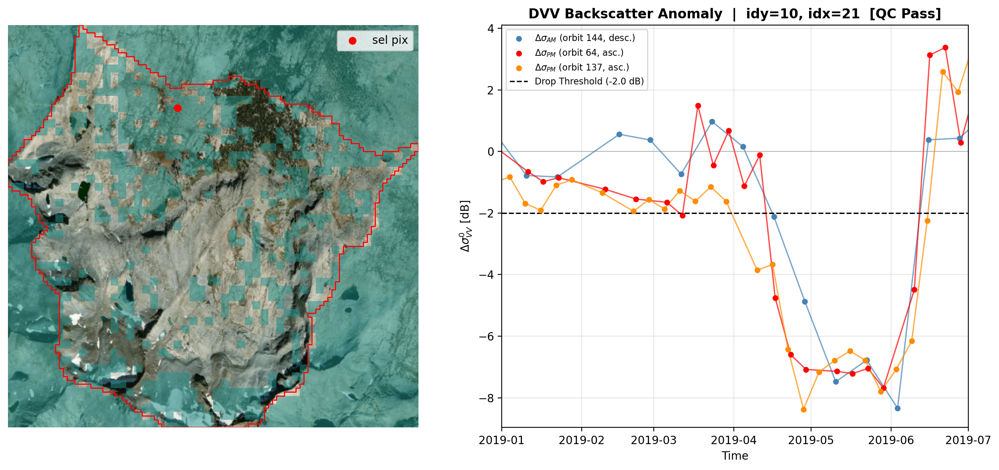

In [26]:

# Random QC-passing pixel
fig, ax = backscatter_anomalies(ds_s1_vv_lyell, 
                                s1_bsc_ds, 
                                s1_ref_ds, 
                                qcPass=True,
                                model = 's1-vv',
                                idx_=21,#21
                                idy_=10,#11
                                geog=lyell_gdf_proj,
                                xmin_ = '2019-01-01',
                                xmax_ = '2019-07-01',
                                )
plt.show()

Pixel  idy=11, idx=21  |  y=4183350.0, x=299750.0  |  qc_ok=True
  orbit  64  ref_linear=0.1181  ref_db=-9.28 dB  DVV range [-9.62, 4.32] dB
  orbit 137  ref_linear=0.0824  ref_db=-10.84 dB  DVV range [-9.33, 3.79] dB
  orbit 144  ref_linear=0.0948  ref_db=-10.23 dB  DVV range [-7.48, 1.90] dB
True OK
{'64': {'ok': True, 'reason': 'OK', 'ref': -9.277104377746582, 't_min': Timestamp('2019-05-11 01:50:34.551724'), 'a_min': -9.618441581726074, 'f_below': 0.391304347826087, 'noisy_diag': {'jackknife_spread_days': 12.0, 'local_n': 8, 'distinct_q10_minus_min_db': 0.3621431350708004, 'local_low_count': 1, 'stability_fail': False, 'distinct_fail': True, 'persist_fail': True, 'noisy': False}}, '137': {'ok': True, 'reason': 'OK', 'ref': -10.842416763305664, 't_min': Timestamp('2019-05-16 01:58:57.315574'), 'a_min': -9.333219528198242, 'f_below': 0.4074074074074074, 'noisy_diag': {'jackknife_spread_days': 5.0, 'local_n': 10, 'distinct_q10_minus_min_db': 0.256256103515625, 'local_low_count': 2, 's

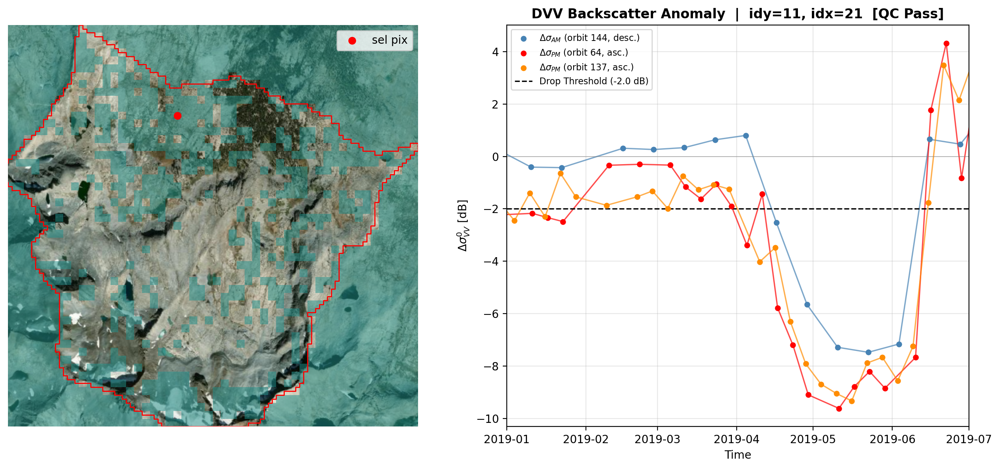

In [27]:

# Random QC-passing pixel
fig, ax = backscatter_anomalies(ds_s1_vv_lyell, 
                                s1_bsc_ds, 
                                s1_ref_ds, 
                                qcPass=True,
                                model = 's1-vv',
                                idx_=21,#6,20,4,23,24
                                idy_=11,#26,13,13,18,13
                                geog=lyell_gdf_proj,
                                xmin_ = '2019-01-01',
                                xmax_ = '2019-07-01',
                                )
plt.show()

# Random QC-failing pixel
# fig, ax = backscatter_anomalies(ds_s1_vv, s1_bsc_ds, s1_ref_ds, qcPass=False)

# Specific pixel
# fig, ax = backscatter_anomalies(ds_s1_vv, s1_bsc_ds, s1_ref_ds, idy_=10, idx_=15)


Pixel  idy=9, idx=21  |  y=4183550.0, x=299750.0  |  qc_ok=True
  orbit  64  ref_linear=0.1216  ref_db=-9.15 dB  DVV range [-8.45, 3.27] dB
  orbit 137  ref_linear=0.0846  ref_db=-10.73 dB  DVV range [-8.35, 2.69] dB
  orbit 144  ref_linear=0.1121  ref_db=-9.50 dB  DVV range [-7.92, 1.41] dB
True OK
{'64': {'ok': True, 'reason': 'OK', 'ref': -9.15136432647705, 't_min': Timestamp('2019-05-11 01:50:34.551724'), 'a_min': -8.447127342224121, 'f_below': 0.34782608695652173, 'noisy_diag': {'jackknife_spread_days': 12.0, 'local_n': 8, 'distinct_q10_minus_min_db': 0.721068572998047, 'local_low_count': 1, 'stability_fail': False, 'distinct_fail': False, 'persist_fail': True, 'noisy': False}}, '137': {'ok': True, 'reason': 'OK', 'ref': -10.726482391357422, 't_min': Timestamp('2019-05-10 01:59:33.045993'), 'a_min': -8.353313446044922, 'f_below': 0.4074074074074074, 'noisy_diag': {'jackknife_spread_days': 17.0, 'local_n': 10, 'distinct_q10_minus_min_db': 0.027431488037109375, 'local_low_count': 4,

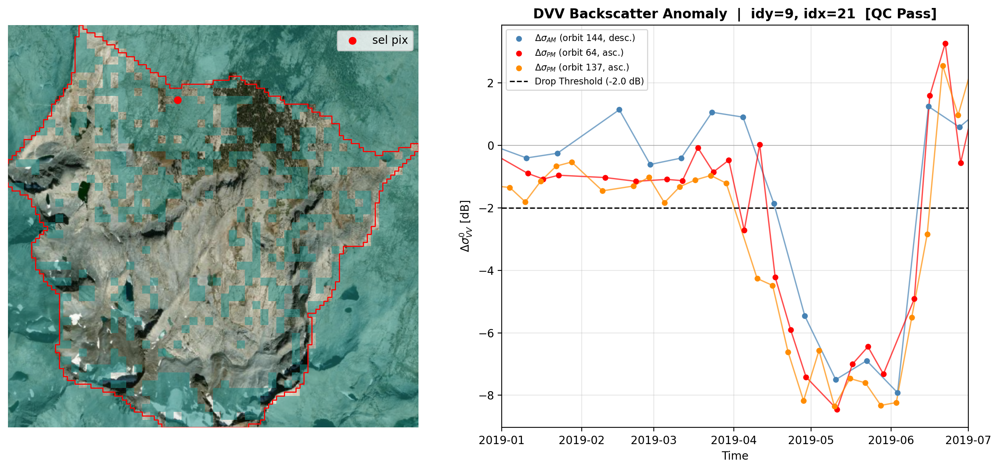

In [28]:

# Random QC-passing pixel
fig, ax = backscatter_anomalies(ds_s1_vv_lyell, 
                                s1_bsc_ds, 
                                s1_ref_ds, 
                                qcPass=True,
                                model = 's1-vv',
                                idx_=21,#6,20,4,23,24
                                idy_=9,#26,13,13,18,13
                                geog=lyell_gdf_proj,
                                xmin_ = '2019-01-01',
                                xmax_ = '2019-07-01',
                                )
plt.show()

Pixel  idy=12, idx=23  |  y=4183250.0, x=299950.0  |  qc_ok=True
  orbit  64  ref_linear=0.1024  ref_db=-9.90 dB  DVV range [-7.79, 4.13] dB
  orbit 137  ref_linear=0.0671  ref_db=-11.73 dB  DVV range [-8.80, 4.82] dB
  orbit 144  ref_linear=0.0911  ref_db=-10.41 dB  DVV range [-8.15, 2.13] dB
True OK
{'64': {'ok': True, 'reason': 'OK', 'ref': -9.897456169128418, 't_min': Timestamp('2019-04-29 01:50:34.349514'), 'a_min': -7.785611152648926, 'f_below': 0.34782608695652173, 'noisy_diag': {'jackknife_spread_days': 12.0, 'local_n': 9, 'distinct_q10_minus_min_db': 0.3026290893554684, 'local_low_count': 3, 'stability_fail': False, 'distinct_fail': True, 'persist_fail': False, 'noisy': False}}, '137': {'ok': True, 'reason': 'OK', 'ref': -11.73401927947998, 't_min': Timestamp('2019-05-10 01:59:33.045993'), 'a_min': -8.799712181091309, 'f_below': 0.4074074074074074, 'noisy_diag': {'jackknife_spread_days': 5.0, 'local_n': 10, 'distinct_q10_minus_min_db': 0.7229158401489251, 'local_low_count': 1,

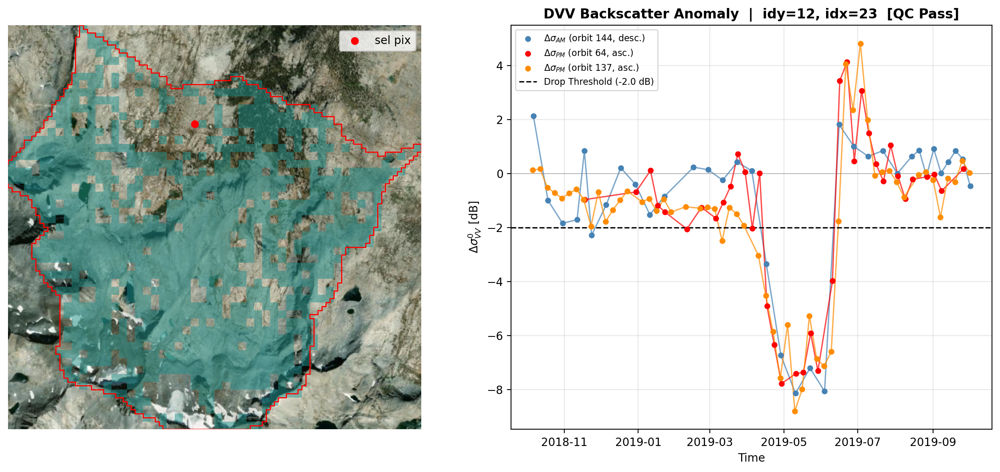

In [29]:
# Random QC-Failing pixel
fig, ax = backscatter_anomalies(ds_s1_vv_lyell, 
                                s1_bsc_ds, 
                                s1_ref_ds, 
                                idx_=23,#8
                                idy_=12,#19
                                qcPass = False,
                                geog=lyell_gdf_proj,
                                )
plt.show()